<a href="https://colab.research.google.com/github/Mstfayldz/MachineLearningNotebooks/blob/master/14-DecisionTreeRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('insurance.csv')

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.shape

(1338, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


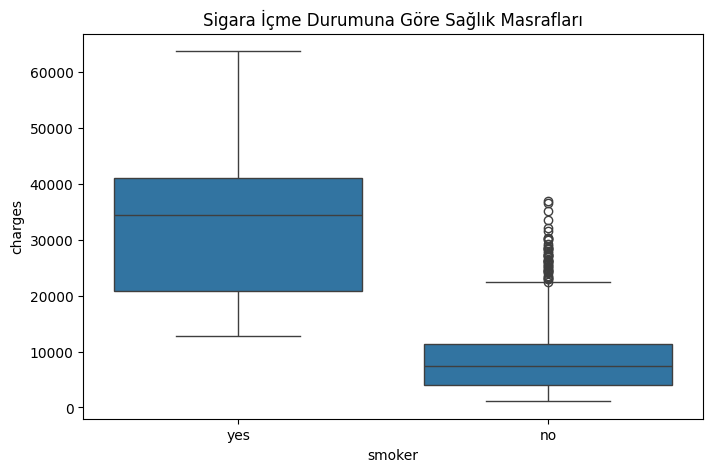

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Sigara İçme Durumuna Göre Sağlık Masrafları')
plt.show()

In [12]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [13]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [14]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [15]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [16]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [17]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [19]:
df.describe()

,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [20]:
X= df.drop('charges',axis=1)
y= df['charges']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [23]:
tree_model = DecisionTreeRegressor(random_state=15)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=15)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [25]:
y_pred = tree_model.predict(X_test)

In [26]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 Skoru:",r2)
print("(MAE):",mae)
print("(RMSE):",rmse)

R2 Skoru: 0.7728779914365734
(MAE): 2680.2012857731343
(RMSE): 5719.425534475229


In [27]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

In [28]:
grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=15), param_grid,cv=5,scoring='r2', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

print("En iyi parametreler:", grid_search_dt.best_params_)
print("En iyi R2 skoru (CV):", grid_search_dt.best_score_)

En iyi parametreler: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
En iyi R2 skoru (CV): 0.8302365195897533


In [29]:
best_tree_model = grid_search_dt.best_estimator_

In [33]:
y_pred_best = best_tree_model.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("--- EN İYİ MODELİN TEST KARNESİ ---")
print(f"Test R2 Skoru: {r2_score(y_test, y_pred_best):.4f}")
print(f"Test MAE (Ortalama Hata): {mean_absolute_error(y_test, y_pred_best):.2f} ")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} ")

--- EN İYİ MODELİN TEST KARNESİ ---
Test R2 Skoru: 0.9016
Test MAE (Ortalama Hata): 2282.16 
Test RMSE: 3763.92 


In [34]:
importances = best_tree_model.feature_importances_
features = X.columns

In [35]:
feature_imp_df = pd.DataFrame({'Özellik': features, 'Önem Derecesi': importances})

In [36]:
feature_imp_df = feature_imp_df.sort_values(by='Önem Derecesi', ascending=False)

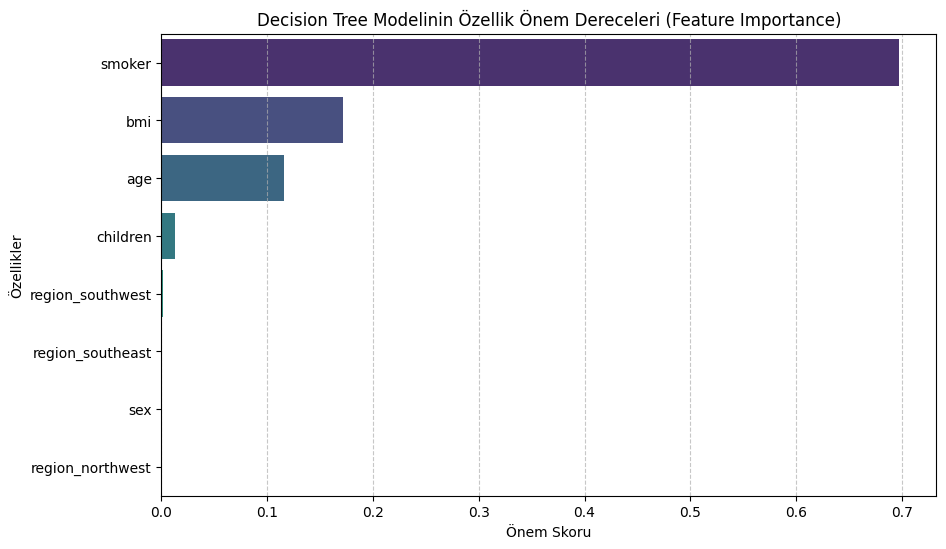

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellik', data=feature_imp_df, hue='Özellik', palette='viridis', legend=False)
plt.title('Decision Tree Modelinin Özellik Önem Dereceleri (Feature Importance)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellikler')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()